In [51]:
"""
Handwritten Digit Recognition Using Neural Networks (MNIST Dataset)
Cybersecurity/AI Internship Project - Naviotech Solution Pvt Ltd
Author: Siva Kumar Reddy
"""

'\nHandwritten Digit Recognition Using Neural Networks (MNIST Dataset)\nCybersecurity/AI Internship Project - Naviotech Solution Pvt Ltd\nAuthor: Siva Kumar Reddy\n'

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

In [53]:
# ---------------------------
# Phase 1: Data Collection
# ---------------------------
print("Phase 1: Loading MNIST dataset...")

Phase 1: Loading MNIST dataset...


In [54]:
import gzip # Not needed when using keras.datasets.mnist.load_data()

In [55]:
def load_images(path): # Not needed when using keras.datasets.mnist.load_data()
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

In [56]:
def load_labels(path): # Not needed when using keras.datasets.mnist.load_data()
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

In [57]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training samples: {x_train.shape[0]}")
print(f"Testing samples: {x_test.shape[0]}")
print(f"Image dimensions: {x_train.shape[1]}x{x_train.shape[2]}")

Training samples: 60000
Testing samples: 10000
Image dimensions: 28x28


In [58]:
# Create a directory to save images and model if it doesn't exist
if not os.path.exists('screenshots'):
    os.makedirs('screenshots')
    print("Created 'screenshots' directory.")

In [59]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digit Images")
plt.tight_layout()

# Ensure the directory exists before saving
if not os.path.exists('screenshots'):
    os.makedirs('screenshots')

plt.savefig('screenshots/01_sample_digits.png', dpi=120)
plt.close()
print("Saved: sample digit images")

Saved: sample digit images


In [60]:
# ---------------------------
# Phase 2: Data Preprocessing
# ---------------------------
print("\nPhase 2: Preprocessing data...")
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
print("Normalization and reshaping complete.")


Phase 2: Preprocessing data...
Normalization and reshaping complete.


In [61]:
# ---------------------------
# Phase 3: Model Development
# ---------------------------
print("\nPhase 3: Building Neural Network model...")
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Phase 3: Building Neural Network model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
with open('screenshots/model_summary.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

In [63]:
# ---------------------------
# Phase 4: Model Training
# ---------------------------
print("\nPhase 4: Training model...")
history = model.fit(
    x_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)


Phase 4: Training model...
Epoch 1/5
422/422 - 43s - 103ms/step - accuracy: 0.9210 - loss: 0.2630 - val_accuracy: 0.9833 - val_loss: 0.0589
Epoch 2/5
422/422 - 81s - 193ms/step - accuracy: 0.9753 - loss: 0.0820 - val_accuracy: 0.9860 - val_loss: 0.0477
Epoch 3/5
422/422 - 41s - 97ms/step - accuracy: 0.9824 - loss: 0.0588 - val_accuracy: 0.9885 - val_loss: 0.0422
Epoch 4/5
422/422 - 41s - 97ms/step - accuracy: 0.9864 - loss: 0.0463 - val_accuracy: 0.9885 - val_loss: 0.0387
Epoch 5/5
422/422 - 41s - 98ms/step - accuracy: 0.9883 - loss: 0.0375 - val_accuracy: 0.9907 - val_loss: 0.0328


In [64]:
# Plot accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o', color='red')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('screenshots/02_accuracy_loss_graph.png', dpi=120)
plt.close()
print("Saved: accuracy/loss graphs")

Saved: accuracy/loss graphs


In [65]:
history = model.fit(
    x_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test_cat)
)
axes[1].plot(history.history['loss'], label='Train Loss', marker='o', color='red')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('screenshots/02_accuracy_loss_graph.png', dpi=120)
plt.close()
print("Saved: accuracy/loss graphs")

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9895 - loss: 0.0339 - val_accuracy: 0.9919 - val_loss: 0.0238
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9918 - val_loss: 0.0245
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9922 - loss: 0.0241 - val_accuracy: 0.9909 - val_loss: 0.0271
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9917 - val_loss: 0.0241
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.9942 - loss: 0.0177 - val_accuracy: 0.9924 - val_loss: 0.0230
Saved: accuracy/loss graphs


In [66]:
# ---------------------------
# Phase 5: Testing and Evaluation
# ---------------------------
print("\nPhase 5: Evaluating model...")
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Phase 5: Evaluating model...
Test Accuracy: 99.24%
Test Loss: 0.0230


In [67]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
report = classification_report(y_test, y_pred)
print(report)
with open('screenshots/classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy: {test_acc*100:.2f}%\nTest Loss: {test_loss:.4f}\n\n")
    f.write(report)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [68]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MNIST Digit Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('screenshots/03_confusion_matrix.png', dpi=120)
plt.close()
print("Saved: confusion matrix")

Saved: confusion matrix


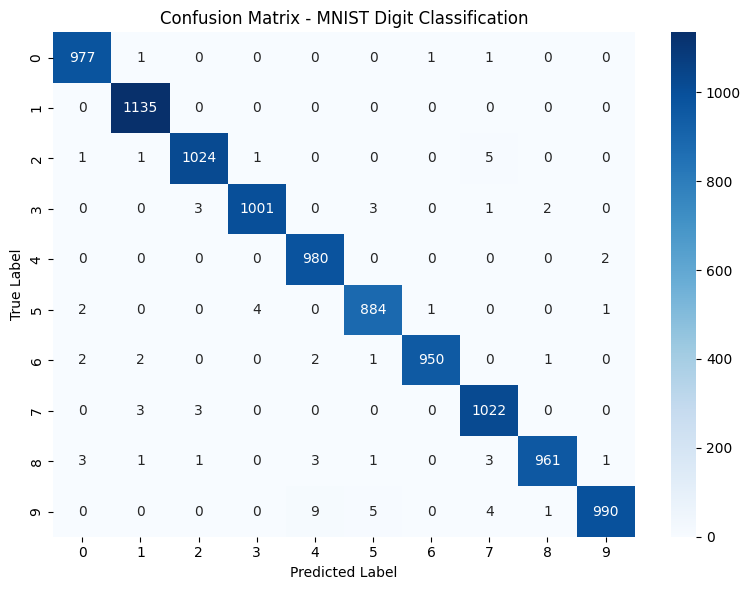

Displayed: confusion matrix


In [69]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MNIST Digit Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
print("Displayed: confusion matrix")

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.9922 - val_loss: 0.0244
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.9944 - loss: 0.0156 - val_accuracy: 0.9919 - val_loss: 0.0264
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.9958 - loss: 0.0127 - val_accuracy: 0.9918 - val_loss: 0.0292
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9938 - val_loss: 0.0213
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9964 - loss: 0.0115 - val_accuracy: 0.9922 - val_loss: 0.0255


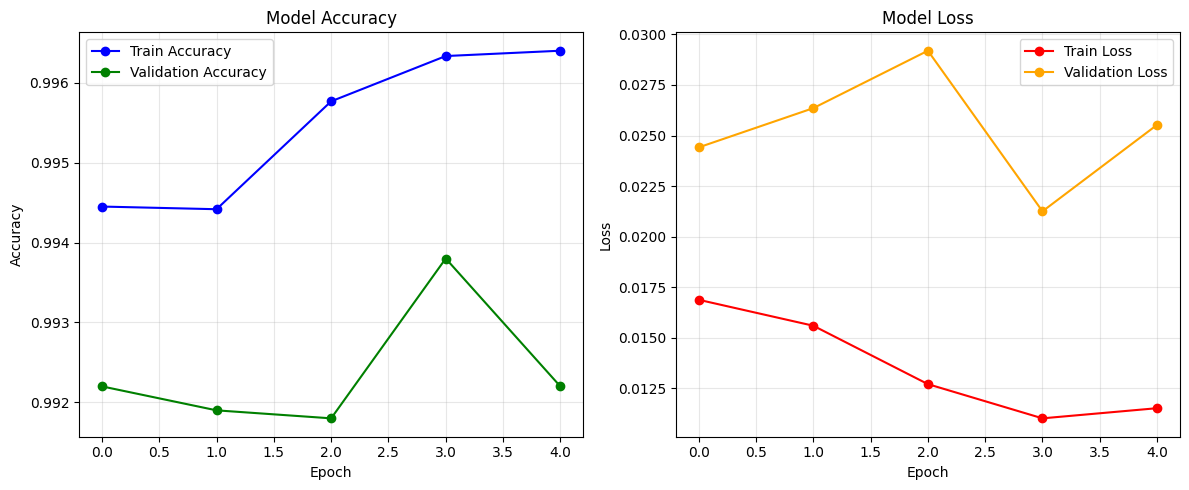

Saved: accuracy/loss graphs


In [70]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("screenshots", exist_ok=True)

# Train the model
history = model.fit(
    x_train,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test_cat)
)

# Create figure with two graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Graph
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='green')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss Graph
axes[1].plot(history.history['loss'], label='Train Loss', marker='o', color='red')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Save graph
plt.tight_layout()
plt.savefig("screenshots/02_accuracy_loss_graph.png", dpi=120)
plt.show()

print("Saved: accuracy/loss graphs")

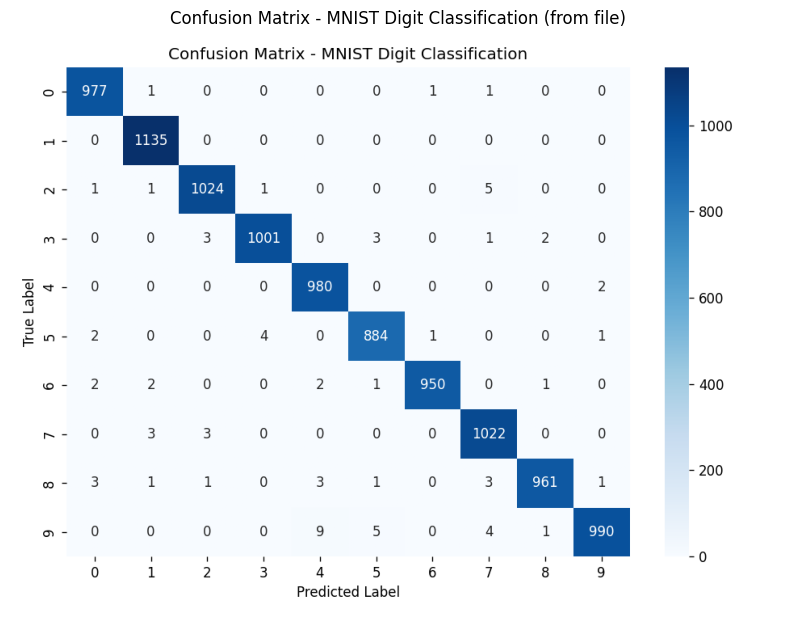

Displayed: Confusion Matrix from screenshots/03_confusion_matrix.png


In [71]:
import matplotlib.pyplot as plt

confusion_matrix_path = 'screenshots/03_confusion_matrix.png'
img = plt.imread(confusion_matrix_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title('Confusion Matrix - MNIST Digit Classification (from file)')
plt.axis('off') # Turn off axis labels and ticks
plt.show()

print(f"Displayed: Confusion Matrix from {confusion_matrix_path}")

In [72]:
# ---------------------------
# Phase 6: Prediction
# ---------------------------
print("\nPhase 6: Sample Predictions...")
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]} | True: {y_test[i]}")
    ax.axis('off')
plt.suptitle("Model Predictions on Test Samples")
plt.tight_layout()
plt.savefig('screenshots/04_predictions.png', dpi=120)
plt.close()
print("Saved: prediction outputs")


Phase 6: Sample Predictions...
Saved: prediction outputs


In [73]:
model.save('mnist_digit_model.h5')
print("\nModel saved as mnist_digit_model.h5")
print(f"\nFINAL TEST ACCURACY: {test_acc*100:.2f}%")


Model saved as mnist_digit_model.h5

FINAL TEST ACCURACY: 99.24%
